<a href="https://colab.research.google.com/github/pravallikachejerla/Data-science/blob/main/purchaseh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


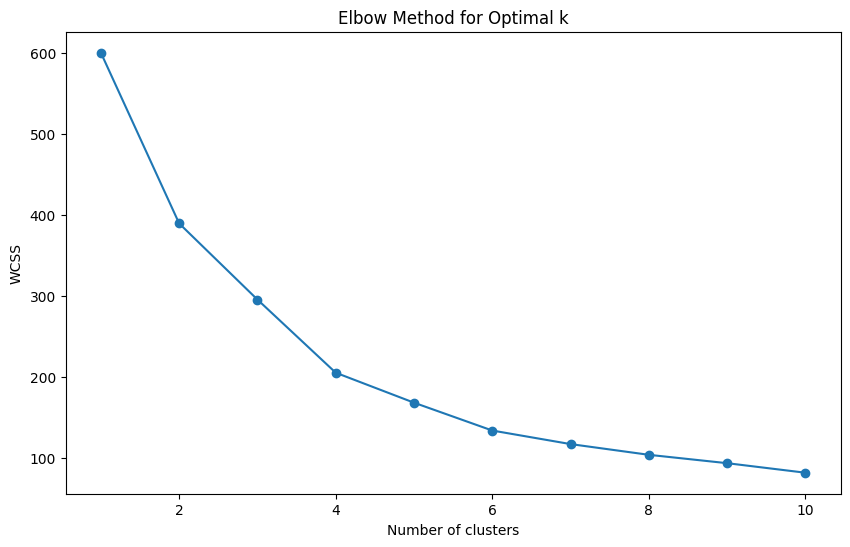

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0        159.743590  0.487179  39.871795           86.102564   
1         83.872340  0.574468  55.638298           54.382979   
2         55.648148  0.592593  25.185185           41.092593   
3         24.100000  0.600000  46.250000           26.750000   
4        161.025000  0.550000  32.875000           86.100000   

         Spending Score (1-100)  
Cluster                          
0                     19.358974  
1                     48.851064  
2                     62.240741  
3                     18.350000  
4                     81.525000  


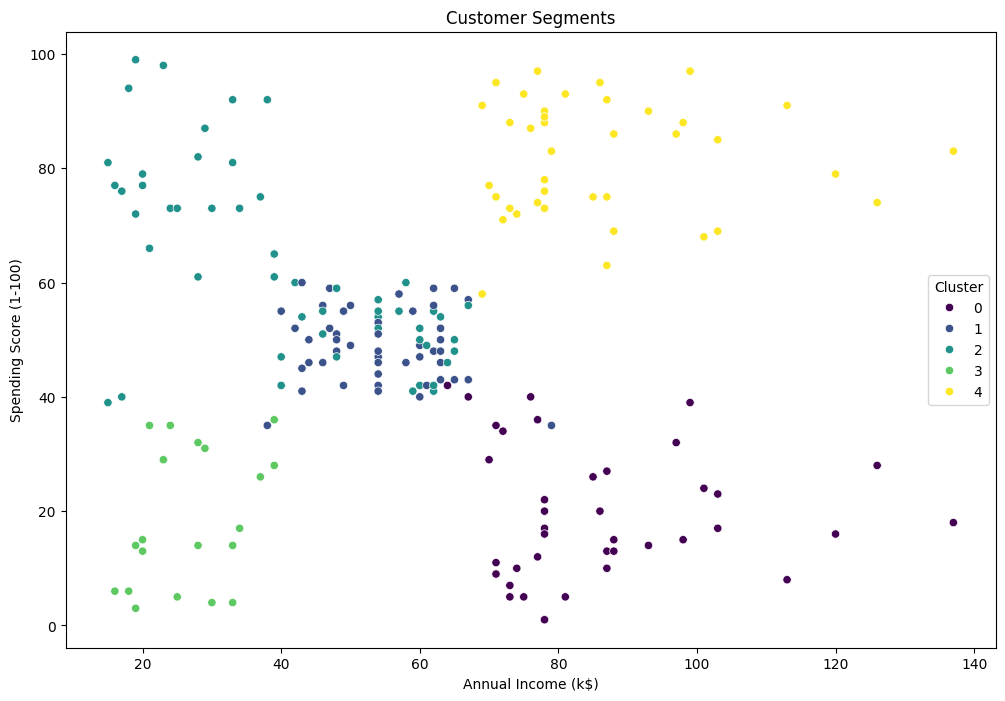

Silhouette Score: 0.42


In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
# Replace 'your_data.csv' with your actual data file
data = pd.read_csv('/content/Mall_Customers.csv')

# Display the first few rows of the dataset
print(data.head())

# Data Preprocessing
# Encoding categorical variables if needed
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})

# Selecting relevant features
features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Normalizing the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Optimal number of clusters (k) determined from the elbow plot
optimal_k = 5  # Example value, adjust based on the plot

# Applying K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels to the original data
data['Cluster'] = clusters

# Analyzing Cluster Characteristics
print(data.groupby('Cluster').mean())

# Visualizing Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=data, palette='viridis')
plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

# Evaluate the clustering performance
silhouette_avg = silhouette_score(scaled_features, clusters)
print(f'Silhouette Score: {silhouette_avg:.2f}')


In [ ]:
# Save the clustering results to a CSV file
data[['CustomerID', 'Cluster']].to_csv('customer_clusters.csv', index=False)


In [ ]:
from google.colab import files
files.download('customer_clusters.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!python customer_segmentation.py


python3: can't open file '/content/customer_segmentation.py': [Errno 2] No such file or directory


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


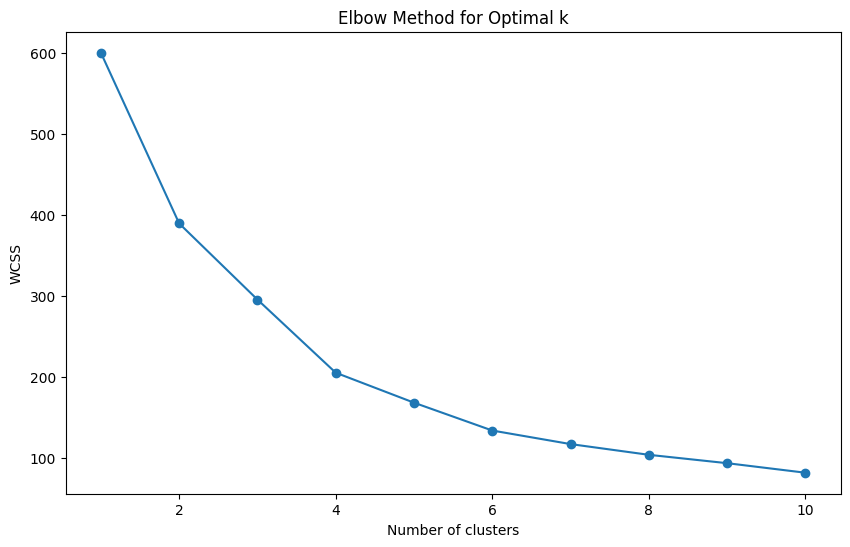

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0        159.743590  0.487179  39.871795           86.102564   
1         83.872340  0.574468  55.638298           54.382979   
2         55.648148  0.592593  25.185185           41.092593   
3         24.100000  0.600000  46.250000           26.750000   
4        161.025000  0.550000  32.875000           86.100000   

         Spending Score (1-100)  
Cluster                          
0                     19.358974  
1                     48.851064  
2                     62.240741  
3                     18.350000  
4                     81.525000  


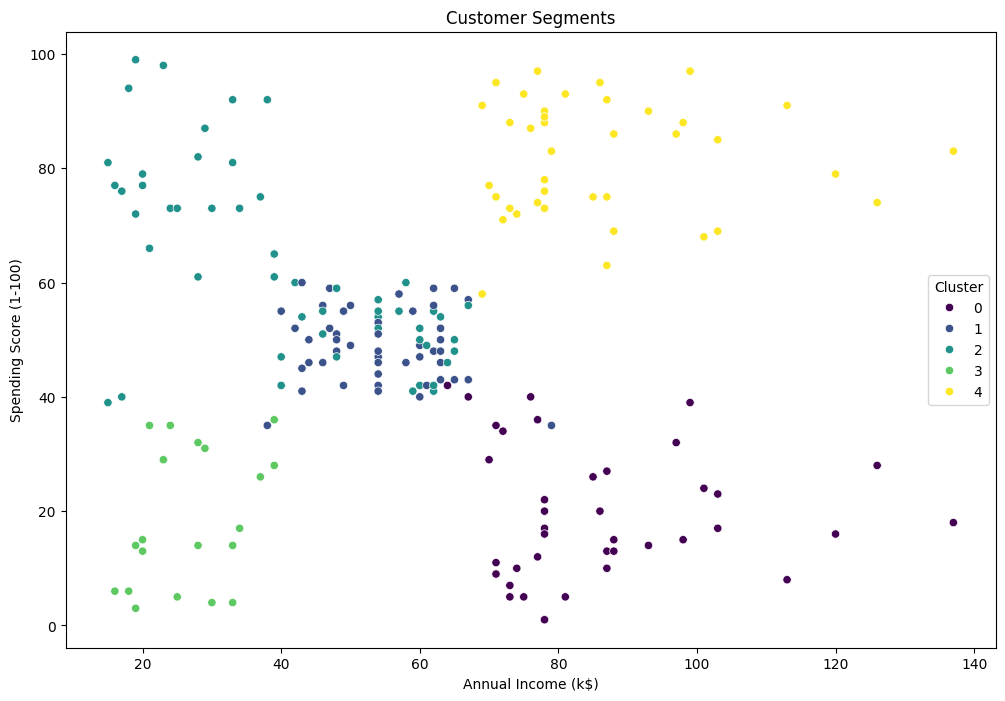

Silhouette Score: 0.42


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
data = pd.read_csv('/content/Mall_Customers.csv')

# Display the first few rows of the dataset
print(data.head())

# Data Preprocessing
# Encoding categorical variables if needed
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})

# Selecting relevant features
features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Normalizing the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.savefig('elbow_method.png')  # Save the plot as an image file
plt.show()

# Optimal number of clusters (k) determined from the elbow plot
optimal_k = 5  # Adjust based on the plot

# Applying K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels to the original data
data['Cluster'] = clusters

# Save the clustering results to a CSV file
data[['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].to_csv('customer_clusters.csv', index=False)

# Analyzing Cluster Characteristics
print(data.groupby('Cluster').mean())

# Visualizing Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=data, palette='viridis')
plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.savefig('clusters_visualization.png')  # Save the plot as an image file
plt.show()

# Evaluate the clustering performance
silhouette_avg = silhouette_score(scaled_features, clusters)
print(f'Silhouette Score: {silhouette_avg:.2f}')

# Download the file if in a Google Colab environment
try:
    from google.colab import files
    files.download('customer_clusters.csv')
except ImportError:
    print("Google Colab not detected; please download the file manually from the working directory.")


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


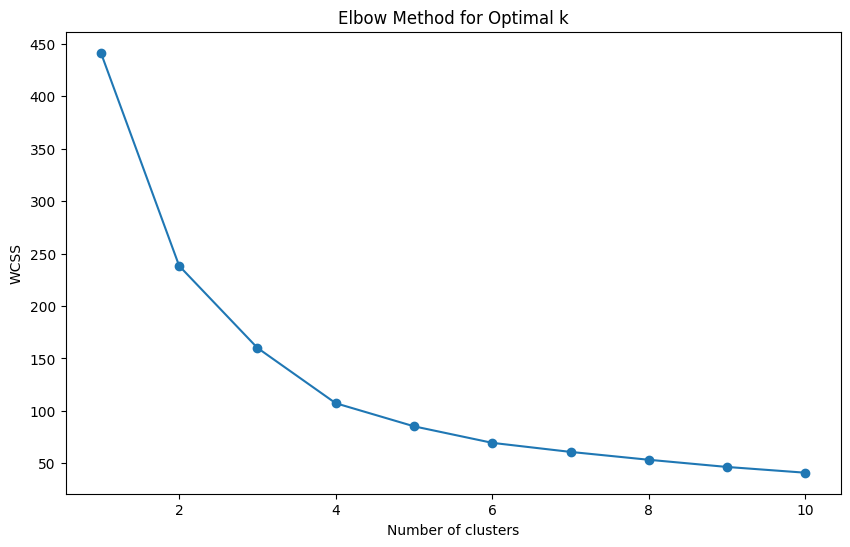

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         63.537037  0.574074  53.814815           45.388889   
1        161.771429  0.571429  32.285714           85.228571   
2         26.703704  0.555556  25.000000           27.629630   
3         97.767442  0.651163  30.023256           59.465116   
4        162.612903  0.483871  44.354839           85.935484   

         Spending Score (1-100)  
Cluster                          
0                     40.648148  
1                     82.257143  
2                     72.851852  
3                     48.209302  
4                     18.774194  


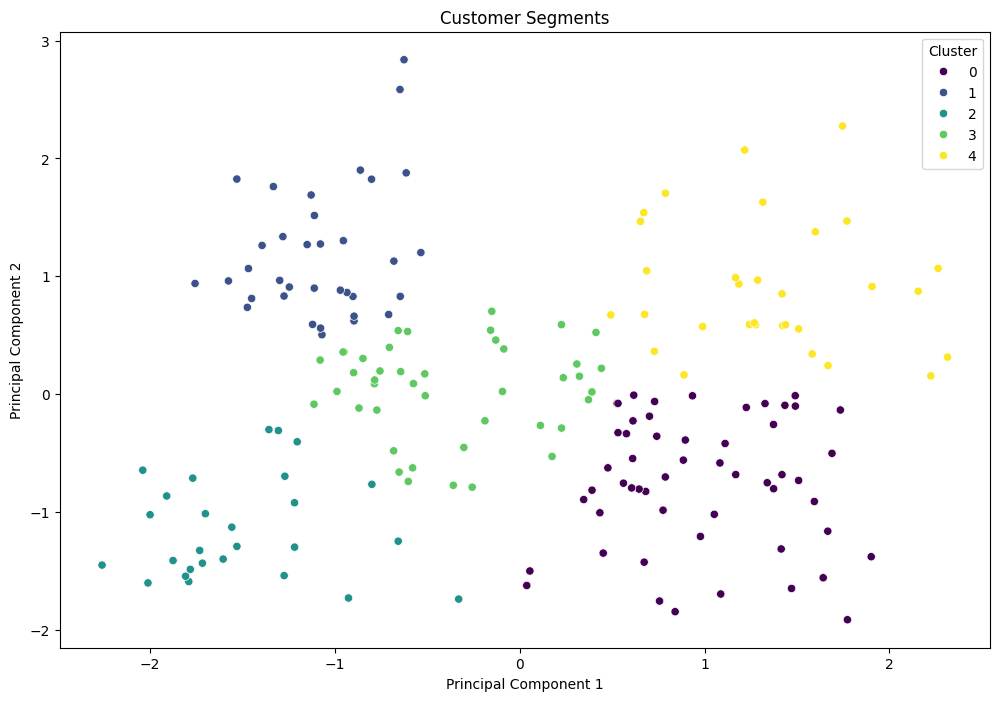

Silhouette Score: 0.41
Silhouette Score for DBSCAN: 0.27


In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

# Load Data
data = pd.read_csv('/content/Mall_Customers.csv')

# Display the first few rows of the dataset
print(data.head())

# Data Preprocessing
# Encoding categorical variables if needed
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})

# Selecting relevant features
features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Outlier Detection using Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=0)
outliers = iso_forest.fit_predict(features)
data['Outlier'] = outliers
data_clean = data[data['Outlier'] == 1].drop(columns='Outlier')

# Feature Scaling
features_clean = data_clean[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_clean)

# Dimensionality Reduction
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(pca_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Optimal number of clusters (k) determined from the elbow plot
optimal_k = 5  # Example value, adjust based on the plot

# Applying K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=0)
clusters = kmeans.fit_predict(pca_features)

# Add cluster labels to the original data
data_clean['Cluster'] = clusters

# Analyzing Cluster Characteristics
print(data_clean.groupby('Cluster').mean())

# Visualizing Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=data_clean['Cluster'], palette='viridis')
plt.title('Customer Segments')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# Evaluate the clustering performance
silhouette_avg = silhouette_score(pca_features, clusters)
print(f'Silhouette Score: {silhouette_avg:.2f}')

# Applying DBSCAN for comparison
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(pca_features)

# Evaluate DBSCAN performance
if len(set(dbscan_clusters)) > 1:  # Ensure there are more than one cluster
    silhouette_dbscan = silhouette_score(pca_features, dbscan_clusters)
    print(f'Silhouette Score for DBSCAN: {silhouette_dbscan:.2f}')
else:
    print('DBSCAN did not find any clusters or found only one cluster.')


In [ ]:
from google.colab import files
files.download('customer_clusters.csv')


FileNotFoundError: Cannot find file: customer_clusters.csv

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


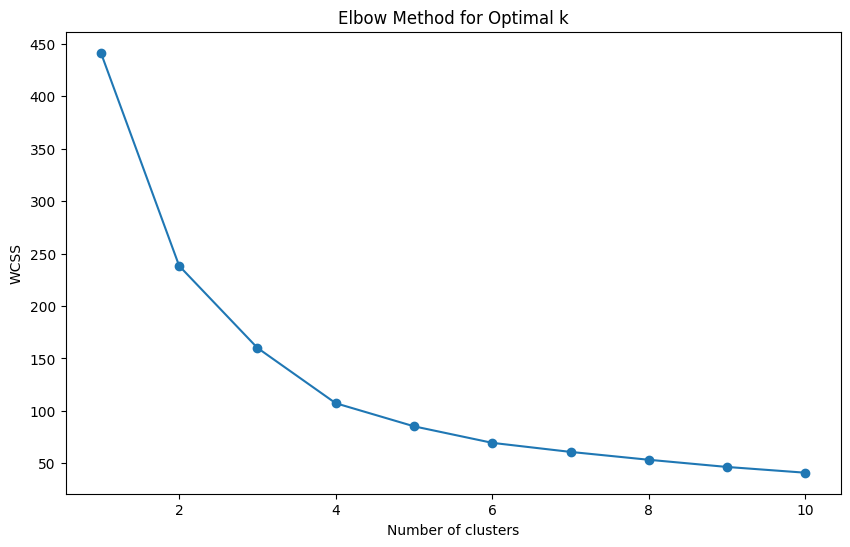

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0         63.537037  0.574074  53.814815           45.388889   
1        161.771429  0.571429  32.285714           85.228571   
2         26.703704  0.555556  25.000000           27.629630   
3         97.767442  0.651163  30.023256           59.465116   
4        162.612903  0.483871  44.354839           85.935484   

         Spending Score (1-100)  
Cluster                          
0                     40.648148  
1                     82.257143  
2                     72.851852  
3                     48.209302  
4                     18.774194  


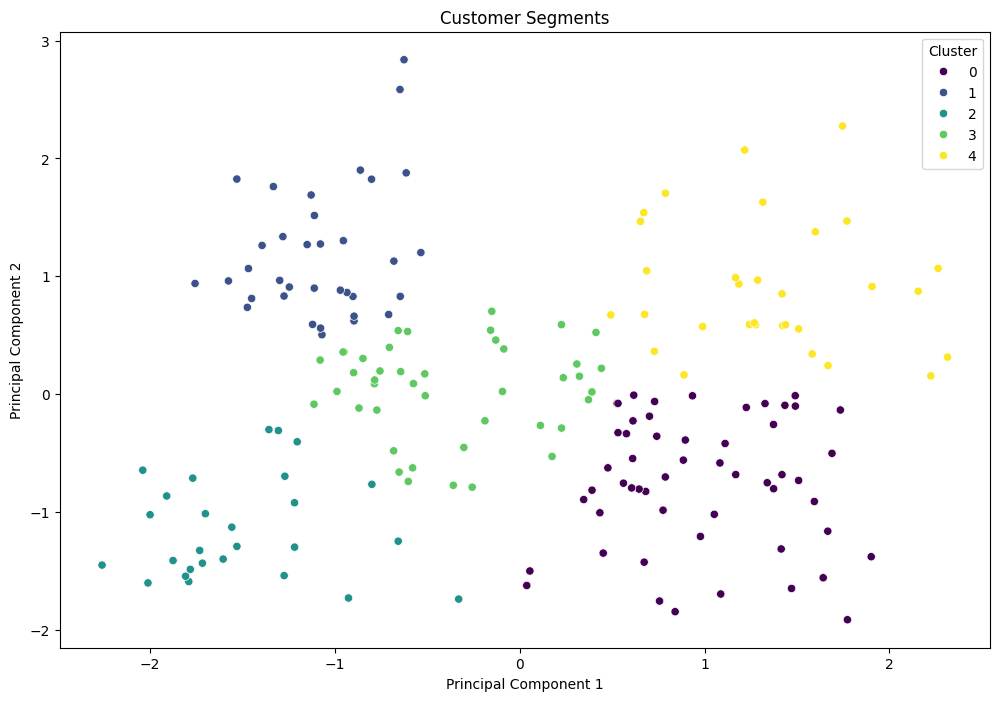

Silhouette Score for K-Means: 0.41
Silhouette Score for DBSCAN: 0.27


In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# Load Data
data = pd.read_csv('/content/Mall_Customers.csv')

# Display the first few rows of the dataset
print(data.head())

# Data Preprocessing
# Encoding categorical variables if needed
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})

# Selecting relevant features
features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Outlier Detection using Isolation Forest
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.05, random_state=0)
outliers = iso_forest.fit_predict(features)
data['Outlier'] = outliers
data_clean = data[data['Outlier'] == 1].drop(columns='Outlier')

# Feature Engineering and Scaling
# Define a pipeline for preprocessing
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Apply preprocessing pipeline
features_clean = data_clean[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaled_features = pipeline.fit_transform(features_clean)

# Dimensionality Reduction
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Determine the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(pca_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Optimal number of clusters (k) determined from the elbow plot
optimal_k = 5  # Example value, adjust based on the plot

# Applying K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=500, n_init=15, random_state=0)
clusters = kmeans.fit_predict(pca_features)

# Add cluster labels to the original data
data_clean['Cluster'] = clusters

# Analyzing Cluster Characteristics
print(data_clean.groupby('Cluster').mean())

# Visualizing Clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=data_clean['Cluster'], palette='viridis')
plt.title('Customer Segments')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# Evaluate the clustering performance
silhouette_avg = silhouette_score(pca_features, clusters)
print(f'Silhouette Score for K-Means: {silhouette_avg:.2f}')

# Applying DBSCAN for comparison
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(pca_features)

# Evaluate DBSCAN performance
if len(set(dbscan_clusters)) > 1:  # Ensure there are more than one cluster
    silhouette_dbscan = silhouette_score(pca_features, dbscan_clusters)
    print(f'Silhouette Score for DBSCAN: {silhouette_dbscan:.2f}')
else:
    print('DBSCAN did not find any clusters or found only one cluster.')
